#  Soybean Yield Prediction Pipeline — v5
**Google Colab — Full Pipeline**

Built on the standardized (soil / micro-climate-weather / target-unit) schema
from v5. This version focuses on the modeling step:

1. **Model comparison** — Ridge, Lasso, Random Forest, **Extra Trees**, XGBoost,
   all evaluated with the same 5-fold temporal CV.
2. **Hyperparameter search** — a randomized search over the tree ensembles
   using the temporal folds as the CV splitter (not a random K-fold, since
   yield data is autocorrelated by year/region).
3. **Final model = stacked ensemble** — Extra Trees + Random Forest + XGBoost
   as base learners, Ridge as the meta-learner. Stacking is used because the
   three trees make *different kinds* of errors (Extra Trees' extra
   randomness decorrelates it from RF/XGB), so blending them tends to beat
   any single tree model on soil/weather tabular data like this.

The country-config / standardization layer from v5 (Steps 1–4) is unchanged —
this version just swaps out Steps 6–9 for a stronger modeling section.


##  STEP 0 — Setup: Install Libraries & Import

In [ ]:
!pip install xgboost lightgbm catboost optuna --quiet

import warnings, json, os, re, time
from dataclasses import dataclass, field
from typing import Callable, Optional
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.ensemble import StackingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.base import clone
import xgboost as xgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120})




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 22.5 MB/s eta 0:00:00


##  STEP 1 — Country Configuration

Single source of truth for the raw → standardized column mapping (soil, weekly
micro-climate/weather, region, target unit). Kept generic in structure, but
only `USA` is active — no Sri Lanka work this round.

In [ ]:
@dataclass
class CountryConfig:
    country_code: str
    raw_path: str
    weather_vars: dict                      # {std_name: raw_prefix}
    weekly_col_pattern: Callable[[str, int], str]
    growing_season_weeks: list
    soil_vars: dict                         # {std_name: raw_prefix}
    soil_depth_regex: Callable[[str], "re.Pattern"]
    region_col: str
    lat_col: str
    lon_col: str
    year_col: str
    raw_target_col: str
    target_unit_to_kg_per_ha: float
    valid_target_range_kg_ha: tuple
    id_cols_to_drop: list = field(default_factory=list)
    baseline_year: int = 1980
    fixed_folds: list = field(default_factory=list)


USA_CONFIG = CountryConfig(
    country_code="USA",
    raw_path="khaki_multi_crop_yield.csv",
    weather_vars={
        "precipitation": "W_1", "solar_radiation": "W_2",
        "snow_water_equivalent": "W_3", "maximum_temperature": "W_4",
        "minimum_temperature": "W_5", "vapor_pressure": "W_6",
    },
    weekly_col_pattern=lambda prefix, week: f"{prefix}_{week}",
    growing_season_weeks=list(range(14, 40)),   # weeks 14-39 ~ May-Sep
    soil_vars={
        "bulk_density": "bdod", "cation_exchange_capacity": "cec",
        "coarse_fragments": "cfvo", "clay_content": "clay",
        "total_nitrogen": "nitrogen", "organic_carbon_density": "ocd",
        "organic_carbon_stocks": "ocs", "soil_ph": "phh2o",
        "sand_content": "sand", "silt_content": "silt",
        "soil_organic_carbon": "soc",
    },
    soil_depth_regex=lambda prefix: re.compile(rf"^{prefix}_mean_(.+)$"),
    region_col="State", lat_col="lat", lon_col="lng", year_col="year",
    raw_target_col="soybean_yield",
    target_unit_to_kg_per_ha=67.25,   # 1 Bu/Acre soybean ≈ 67.25 kg/ha
    valid_target_range_kg_ha=(5 * 67.25, 100 * 67.25),
    id_cols_to_drop=["corn_yield", "winter_wheat_yield"],
    baseline_year=1980,
    fixed_folds=[
        {"train_max_year": 2013, "test_year": 2014},
        {"train_max_year": 2014, "test_year": 2015},
        {"train_max_year": 2015, "test_year": 2016},
        {"train_max_year": 2016, "test_year": 2017},
        {"train_max_year": 2017, "test_year": 2018},
    ],
)

cfg = USA_CONFIG
print(f"Active config: {cfg.country_code}  ->  {cfg.raw_path}")

Active config: USA  ->  khaki_multi_crop_yield.csv


##  STEP 2 — Load Raw Data

In [ ]:
import os

# ── OPTION A: Upload from local computer ──────────────────────
from google.colab import drive
drive.mount('/content/drive')

RAW_PATH = '/content/drive/MyDrive/khaki_multi_crop_yield.csv'

raw = pd.read_csv(RAW_PATH)
print(f"Loaded {RAW_PATH}: {len(raw):,} rows x {raw.shape[1]} columns")


Mounted at /content/drive
Loaded /content/drive/MyDrive/khaki_multi_crop_yield.csv: 25,306 rows x 401 columns


##  STEP 3 — Standardize + Clean

STEP 3 — Standardizing & Cleaning
  Dropped 0 rows with missing target. Remaining: 25306
  Dropped 0 exact duplicate rows.
  Removed 0 extreme yield outliers (IQR x3 per region).
  Clipped to [336, 6725] kg/ha; removed 2 rows. Final: 25304


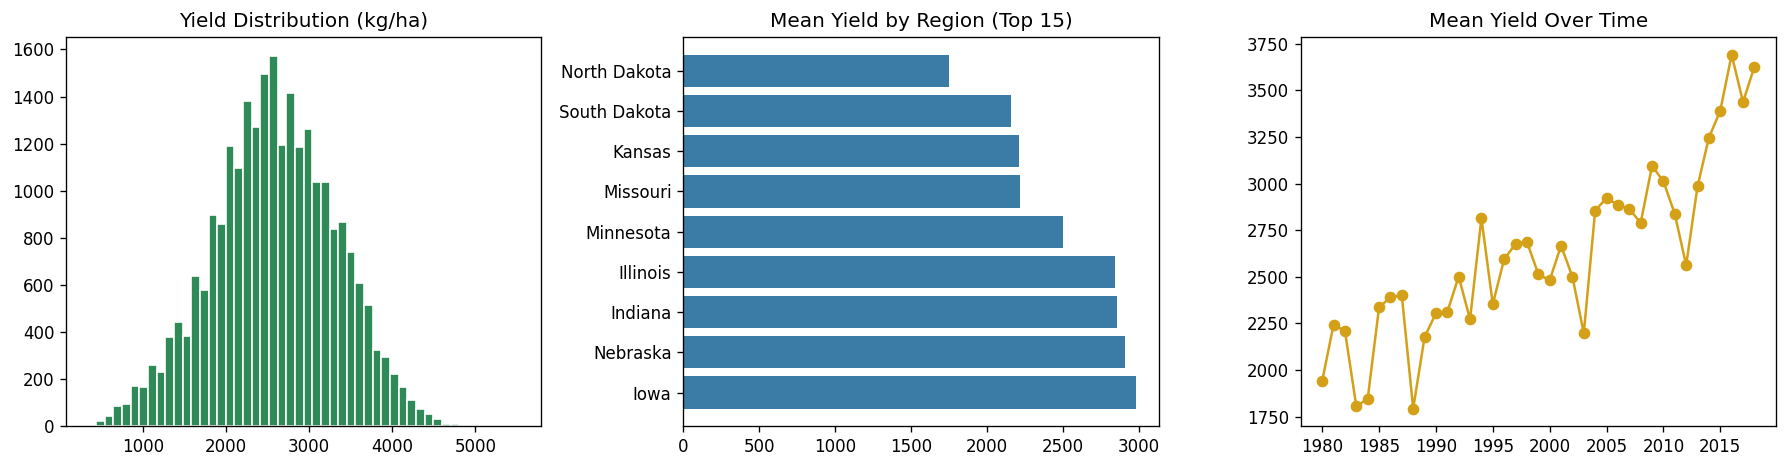

In [ ]:
def standardize_and_clean(df_raw: pd.DataFrame, cfg: CountryConfig) -> pd.DataFrame:
    print('=' * 65); print('STEP 3 — Standardizing & Cleaning'); print('=' * 65)
    df = df_raw.copy()
    df = df.drop(columns=cfg.id_cols_to_drop, errors='ignore')

    df['yield_kg_ha'] = df[cfg.raw_target_col] * cfg.target_unit_to_kg_per_ha
    before = len(df)
    df = df.dropna(subset=['yield_kg_ha'])
    print(f'  Dropped {before - len(df)} rows with missing target. Remaining: {len(df)}')

    before = len(df)
    df = df.drop_duplicates()
    print(f'  Dropped {before - len(df)} exact duplicate rows.')

    df['region'] = df[cfg.region_col].astype(str).str.strip().str.title()
    df['latitude'] = df[cfg.lat_col]
    df['longitude'] = df[cfg.lon_col]
    df['obs_year'] = df[cfg.year_col]
    df['country'] = cfg.country_code

    def iqr_outlier_mask(series, factor=3.0):
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        return (series >= q1 - factor * iqr) & (series <= q3 + factor * iqr)

    before = len(df)
    mask = df.groupby('region')['yield_kg_ha'].transform(iqr_outlier_mask)
    df = df[mask].copy()
    print(f'  Removed {before - len(df)} extreme yield outliers (IQR x3 per region).')

    lo, hi = cfg.valid_target_range_kg_ha
    before = len(df)
    df = df[(df['yield_kg_ha'] >= lo) & (df['yield_kg_ha'] <= hi)]
    print(f'  Clipped to [{lo:.0f}, {hi:.0f}] kg/ha; removed {before - len(df)} rows. Final: {len(df)}')
    return df


df_clean = standardize_and_clean(raw, cfg)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_clean['yield_kg_ha'], bins=50, color='#2E8B57', edgecolor='white')
axes[0].set_title('Yield Distribution (kg/ha)')
yield_by_region = df_clean.groupby('region')['yield_kg_ha'].mean().sort_values(ascending=False).head(15)
axes[1].barh(yield_by_region.index, yield_by_region.values, color='#3A7CA5')
axes[1].set_title('Mean Yield by Region (Top 15)')
yield_by_year = df_clean.groupby('obs_year')['yield_kg_ha'].mean()
axes[2].plot(yield_by_year.index, yield_by_year.values, marker='o', color='#D4A017')
axes[2].set_title('Mean Yield Over Time')
plt.tight_layout()
plt.savefig('/content/eda_overview.png', bbox_inches='tight')
plt.show()

In [ ]:
ARTIFACT_DIR = '/content/artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

##  STEP 4 — Feature Engineering (Soil + Micro-Climate/Weather)

Final feature set is deliberately built from exactly the three signal groups
the model is meant to learn from: **soil properties**, **micro-climate /
weekly weather aggregates**, and **location/time context** (lat/lon/region/year)
needed to situate the soil+weather readings. No production/economic columns
(area planted, expenses, etc.) are included — those are outcomes, not
predictors, and including them would leak information.

In [ ]:
def engineer_features(df: pd.DataFrame, cfg: CountryConfig, region_encoder: Optional[LabelEncoder] = None):
    print('=' * 65); print('STEP 4 — Feature Engineering'); print('=' * 65)
    feat = df.copy()

    # Growing-season + annual weather aggregates (micro-climate signal)
    for std_name, prefix in cfg.weather_vars.items():
        all_week_cols = [cfg.weekly_col_pattern(prefix, w) for w in range(1, 53)
                          if cfg.weekly_col_pattern(prefix, w) in feat.columns]
        gs_cols = [cfg.weekly_col_pattern(prefix, w) for w in cfg.growing_season_weeks
                   if cfg.weekly_col_pattern(prefix, w) in feat.columns]
        if gs_cols:
            feat[f'growing_season_{std_name}_mean'] = feat[gs_cols].mean(axis=1)
            feat[f'growing_season_{std_name}_sum']  = feat[gs_cols].sum(axis=1)
            feat[f'growing_season_{std_name}_std']  = feat[gs_cols].std(axis=1)
        if all_week_cols:
            feat[f'annual_{std_name}_mean'] = feat[all_week_cols].mean(axis=1)

    # Weather interaction terms — capture compounding stress (heat x dryness, etc.)
    if {'growing_season_maximum_temperature_mean', 'growing_season_minimum_temperature_mean'} <= set(feat.columns):
        feat['growing_season_diurnal_temperature_range'] = (
            feat['growing_season_maximum_temperature_mean'] - feat['growing_season_minimum_temperature_mean'])
    if {'growing_season_precipitation_mean', 'growing_season_solar_radiation_mean'} <= set(feat.columns):
        feat['growing_season_precipitation_x_solar_radiation'] = (
            feat['growing_season_precipitation_mean'] * feat['growing_season_solar_radiation_mean'])
    if {'growing_season_vapor_pressure_mean', 'growing_season_maximum_temperature_mean'} <= set(feat.columns):
        feat['growing_season_vapor_pressure_x_max_temperature'] = (
            feat['growing_season_vapor_pressure_mean'] * feat['growing_season_maximum_temperature_mean'])
    # Heat-stress proxy: degree-days above 30C across growing season, if max-temp weeks exist
    max_temp_prefix = cfg.weather_vars.get('maximum_temperature')
    if max_temp_prefix:
        gs_max_cols = [cfg.weekly_col_pattern(max_temp_prefix, w) for w in cfg.growing_season_weeks
                       if cfg.weekly_col_pattern(max_temp_prefix, w) in feat.columns]
        if gs_max_cols:
            feat['growing_season_heat_stress_degree_days'] = (feat[gs_max_cols] - 30).clip(lower=0).sum(axis=1)
    # Water-balance proxy: precip minus a temperature-driven evap proxy
    if {'growing_season_precipitation_sum', 'growing_season_maximum_temperature_mean'} <= set(feat.columns):
        feat['growing_season_water_balance_proxy'] = (
            feat['growing_season_precipitation_sum'] - feat['growing_season_maximum_temperature_mean'] * 10)

    # Soil aggregates (soil signal)
    for std_name, prefix in cfg.soil_vars.items():
        pattern = cfg.soil_depth_regex(prefix)
        depth_cols = [c for c in feat.columns if pattern.match(c)]
        if depth_cols:
            feat[f'{std_name}_depth_averaged_mean'] = feat[depth_cols].mean(axis=1)
            feat[f'{std_name}_topsoil_mean'] = feat[sorted(depth_cols)[0]]
    # Soil interaction: water-holding capacity proxy (clay + organic carbon)
    if {'clay_content_depth_averaged_mean', 'soil_organic_carbon_depth_averaged_mean'} <= set(feat.columns):
        feat['soil_water_holding_proxy'] = (
            feat['clay_content_depth_averaged_mean'] + feat['soil_organic_carbon_depth_averaged_mean'])
    # Soil x weather interaction: sandy soil compounds drought stress
    if {'sand_content_depth_averaged_mean', 'growing_season_precipitation_sum'} <= set(feat.columns):
        feat['sand_x_low_precipitation'] = (
            feat['sand_content_depth_averaged_mean'] / (feat['growing_season_precipitation_sum'] + 1))

    # Region encoding
    if region_encoder is None:
        region_encoder = LabelEncoder()
        feat['region_encoded'] = region_encoder.fit_transform(feat['region'])
    else:
        feat['region_encoded'] = region_encoder.transform(feat['region'])

    feat['years_since_baseline'] = feat['obs_year'] - cfg.baseline_year
    return feat, region_encoder


feat, region_encoder = engineer_features(df_clean, cfg)
joblib.dump(region_encoder, f'{ARTIFACT_DIR}/region_encoder.joblib')
print(f'  Engineered shape: {feat.shape}')

STEP 4 — Feature Engineering
  Engineered shape: (25304, 460)


##  STEP 5 — Export Cleaned & Engineered CSV

In [ ]:
OUTPUT_PATH = '/content/yield_cleaned_engineered.csv'
feat.to_csv(OUTPUT_PATH, index=False)
print(f'  Saved -> {OUTPUT_PATH}  ({len(feat):,} rows x {feat.shape[1]} cols)')

from google.colab import files
files.download(OUTPUT_PATH)

  Saved -> /content/yield_cleaned_engineered.csv  (25,304 rows x 460 cols)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import warnings
import json
import os
import re
from dataclasses import dataclass, field
from typing import Callable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.cluster import KMeans
import xgboost as xgb

##  STEP 6 — K-Means Clustering (Agro-Climatic Profiles)

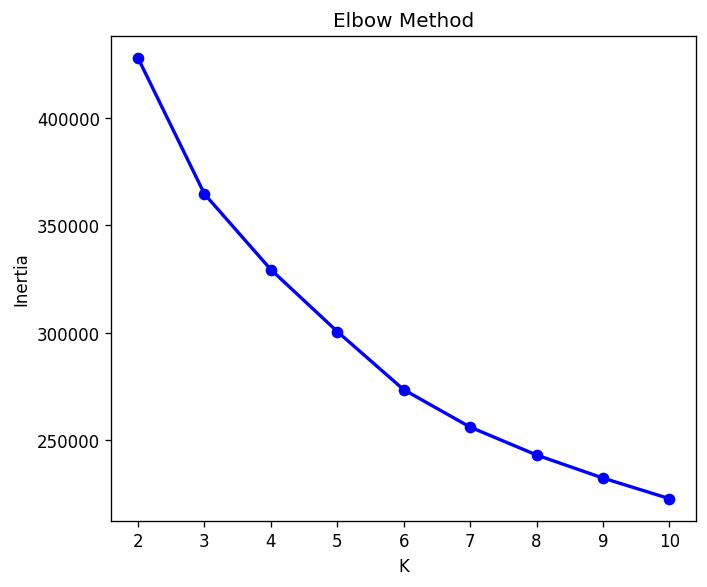

['/content/artifacts/cluster_artifacts.joblib']

In [ ]:
# Soil + weather only -- intentionally NOT including latitude/longitude here,
# so the resulting cluster id is an agro-climatic profile (soil+weather
# signature) rather than a stand-in for "which region is this".
cluster_feature_cols = (
    [f'growing_season_{v}_mean' for v in cfg.weather_vars] +
    [f'growing_season_{v}_sum'  for v in cfg.weather_vars] +
    [f'{v}_depth_averaged_mean' for v in cfg.soil_vars]
)
cluster_feature_cols = [c for c in cluster_feature_cols if c in feat.columns]

X_cluster = feat[cluster_feature_cols].fillna(0).values
scaler_c = StandardScaler()
X_cluster_s = scaler_c.fit_transform(X_cluster)

inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_s)
    inertias.append(km.inertia_)

K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
feat['cluster'] = kmeans.fit_predict(X_cluster_s)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(list(K_range), inertias, 'bo-', linewidth=2)
ax.set_title('Elbow Method'); ax.set_xlabel('K'); ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('/content/clustering_results.png', bbox_inches='tight')
plt.show()

joblib.dump({'scaler': scaler_c, 'kmeans': kmeans, 'feature_cols': cluster_feature_cols},
            f'{ARTIFACT_DIR}/cluster_artifacts.joblib')

##  STEP 7 — Final Feature Set & Temporal Folds

In [ ]:
def build_feature_cols(feat: pd.DataFrame, cfg: CountryConfig) -> list:
    # Soil + micro-climate/weather, plus ONE deliberate exception:
    # years_since_baseline. region_encoded/latitude/longitude are LOCATION
    # identifiers -- categorical/coordinate stand-ins for "which US state is
    # this" that have no meaning in another country's dataset, so they're
    # excluded. years_since_baseline is different: it's a continuous TIME
    # trend (every country has a calendar) that captures real genetic/
    # technology yield improvement over the decades -- a physical driver,
    # not a memorized location. Dropping it left tree models with no way to
    # extrapolate the upward yield trend into later test years, which is why
    # removing it caused R^2 to collapse. 'cluster' is kept because it's
    # built purely from soil+weather signatures (see Step 6) -- not a
    # location proxy.
    cols = (
        [f'growing_season_{v}_mean' for v in cfg.weather_vars] +
        [f'growing_season_{v}_sum'  for v in cfg.weather_vars] +
        [f'growing_season_{v}_std'  for v in cfg.weather_vars] +
        [f'annual_{v}_mean'         for v in cfg.weather_vars] +
        [f'{v}_depth_averaged_mean' for v in cfg.soil_vars] +
        [f'{v}_topsoil_mean'        for v in cfg.soil_vars] +
        ['growing_season_diurnal_temperature_range',
         'growing_season_precipitation_x_solar_radiation',
         'growing_season_vapor_pressure_x_max_temperature',
         'growing_season_heat_stress_degree_days',
         'growing_season_water_balance_proxy',
         'soil_water_holding_proxy',
         'sand_x_low_precipitation',
         'years_since_baseline', 'cluster']
    )
    return [c for c in cols if c in feat.columns]


TARGET = 'yield_kg_ha'
feature_cols = build_feature_cols(feat, cfg)
folds = cfg.fixed_folds

print(f'  Features used: {len(feature_cols)}')
for c in feature_cols:
    print('   -', c)

json.dump({'feature_cols': feature_cols, 'target': TARGET},
          open(f'{ARTIFACT_DIR}/feature_schema.json', 'w'), indent=2)

  Features used: 55
   - growing_season_precipitation_mean
   - growing_season_solar_radiation_mean
   - growing_season_snow_water_equivalent_mean
   - growing_season_maximum_temperature_mean
   - growing_season_minimum_temperature_mean
   - growing_season_vapor_pressure_mean
   - growing_season_precipitation_sum
   - growing_season_solar_radiation_sum
   - growing_season_snow_water_equivalent_sum
   - growing_season_maximum_temperature_sum
   - growing_season_minimum_temperature_sum
   - growing_season_vapor_pressure_sum
   - growing_season_precipitation_std
   - growing_season_solar_radiation_std
   - growing_season_snow_water_equivalent_std
   - growing_season_maximum_temperature_std
   - growing_season_minimum_temperature_std
   - growing_season_vapor_pressure_std
   - annual_precipitation_mean
   - annual_solar_radiation_mean
   - annual_snow_water_equivalent_mean
   - annual_maximum_temperature_mean
   - annual_minimum_temperature_mean
   - annual_vapor_pressure_mean
   - bulk_de

##  STEP 8 — Model Comparison: Ridge, Lasso, Random Forest, Extra Trees, XGBoost

Same 5-fold temporal CV as before, now with **Extra Trees** added alongside
Random Forest and XGBoost. Extra Trees splits on randomly chosen thresholds
(not the locally-optimal ones RF picks), which trades a bit of per-tree fit
for lower variance and faster training — useful here since soil/weather
features are noisy and somewhat collinear.

In [ ]:
N_TRIALS = 200

MODEL_FACTORIES = {
 'XGBoost': lambda p={}: xgb.XGBRegressor(random_state=42, verbosity=0, **p),
 'LightGBM': lambda p={}: LGBMRegressor(random_state=42, **p)
}


##  STEP 9 — Hyperparameter Search on the Tree Ensembles

`RandomizedSearchCV` needs an explicit list of (train_idx, test_idx) pairs to
respect the temporal folds — a plain K-fold would leak future years into
training. `PredefinedTemporalSplit` builds exactly that from `folds`.

In [ ]:
X_all = feat[feature_cols].fillna(0).values
y_all = feat[TARGET].values
tscv = TimeSeriesSplit(n_splits=5)

# def objective(trial, model_name):
#     if model_name=='XGBoost':
#         params={'n_estimators':trial.suggest_int('n_estimators',100,1000),
#                 'max_depth':trial.suggest_int('max_depth',3,10),
#                 'learning_rate':trial.suggest_float('learning_rate',0.01,0.3)}
#     elif model_name=='LightGBM':
#         params={'n_estimators':trial.suggest_int('n_estimators',100,1000),
#                 'num_leaves':trial.suggest_int('num_leaves',20,100),
#                 'learning_rate':trial.suggest_float('learning_rate',0.01,0.3)}
#     else:
#         params={'iterations':trial.suggest_int('iterations',100,1000),
#                 'depth':trial.suggest_int('depth',4,10),
#                 'learning_rate':trial.suggest_float('learning_rate',0.01,0.3)}
#     model = MODEL_FACTORIES[model_name](params)
#     scores=[]
#     for tr,te in tscv.split(X_all):
#         model.fit(X_all[tr], y_all[tr])
#         pred=model.predict(X_all[te])
#         scores.append(mean_squared_error(y_all[te], pred))
#     return np.mean(scores)

# best_params={}

best_params = {
    'XGBoost': {
        'n_estimators':  809,
        'max_depth':     7,
        'learning_rate': 0.08132085392477892
    },
    'LightGBM': {
        'n_estimators':  909,
        'num_leaves':    54,
        'learning_rate': 0.054229279797255184
    }
}

# Verify
# for m, p in best_params.items():
#     print(f"{m}: {p}")
# for m in MODEL_FACTORIES:
#     study=optuna.create_study(direction='minimize')
#     study.optimize(lambda t: objective(t,m), n_trials=N_TRIALS)
#     best_params[m]=study.best_params
#     print(m, best_params[m])


##  STEP 10 — Final Model: Stacked Ensemble

The tuned Extra Trees, Random Forest, and XGBoost from Step 9 become base
learners in a `StackingRegressor`, with Ridge as the meta-learner blending
their outputs. Stacking is evaluated against each tuned model individually
on the same temporal folds, so you can see exactly how much (if any) the
ensemble buys over the single best tree model — if stacking doesn't help on
your data, the comparison table makes that obvious and you can just deploy
the best individual model instead.

In [ ]:
final_candidates = {
 m: MODEL_FACTORIES[m](best_params[m]) for m in MODEL_FACTORIES
}

stack = StackingRegressor(
 estimators=[('xgb', final_candidates['XGBoost']),
            ('lgbm', final_candidates['LightGBM'])],
 final_estimator=Ridge(alpha=1.0)
)
final_candidates['Stacking Ensemble']=stack

results=[]
for name, model in final_candidates.items():
    rmses=[]; r2s=[]
    for tr,te in tscv.split(X_all):
        model.fit(X_all[tr], y_all[tr])
        pred=model.predict(X_all[te])
        rmses.append(np.sqrt(mean_squared_error(y_all[te], pred)))
        r2s.append(r2_score(y_all[te], pred))
    results.append([name,np.mean(rmses),np.mean(r2s)])

final_summary_df = pd.DataFrame(results, columns=['Model','Mean RMSE (kg/ha)','Mean R²']).sort_values('Mean RMSE (kg/ha)')
FINAL_MODEL_NAME = final_summary_df.iloc[0]['Model']


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10453
[LightGBM] [Info] Number of data points in the train set: 4219, number of used features: 55
[LightGBM] [Info] Start training from score 2679.451042
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001857 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13169
[LightGBM] [Info] Number of data points in the train set: 8436, number of used features: 55
[LightGBM] [Info] Start training from score 2672.274730
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003451 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

##  STEP 11 — Feature Importance & Predicted-vs-Actual (Final Model)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004759 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13550
[LightGBM] [Info] Number of data points in the train set: 24833, number of used features: 55
[LightGBM] [Info] Start training from score 2570.031882
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003712 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13537
[LightGBM] [Info] Number of data points in the train set: 19866, number of used features: 55
[LightGBM] [Info] Start training from score 2544.950423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is n

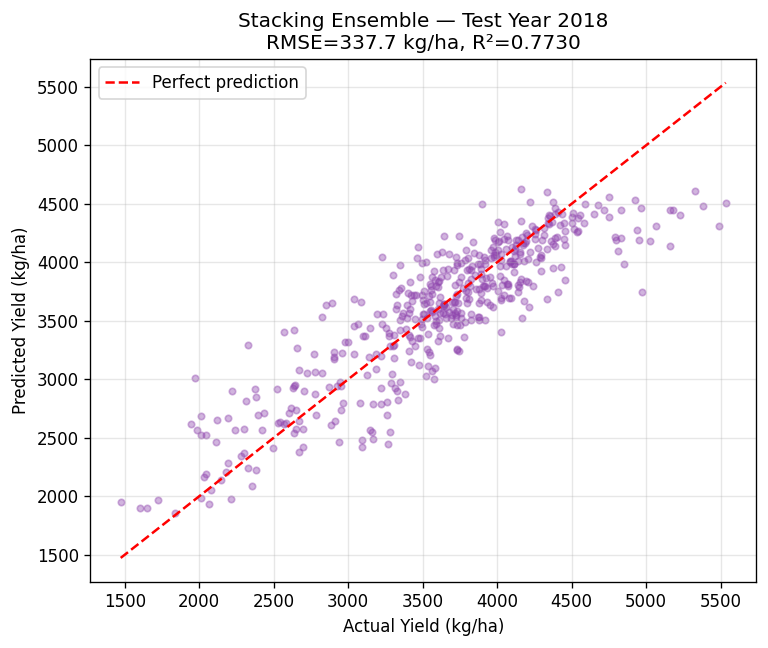

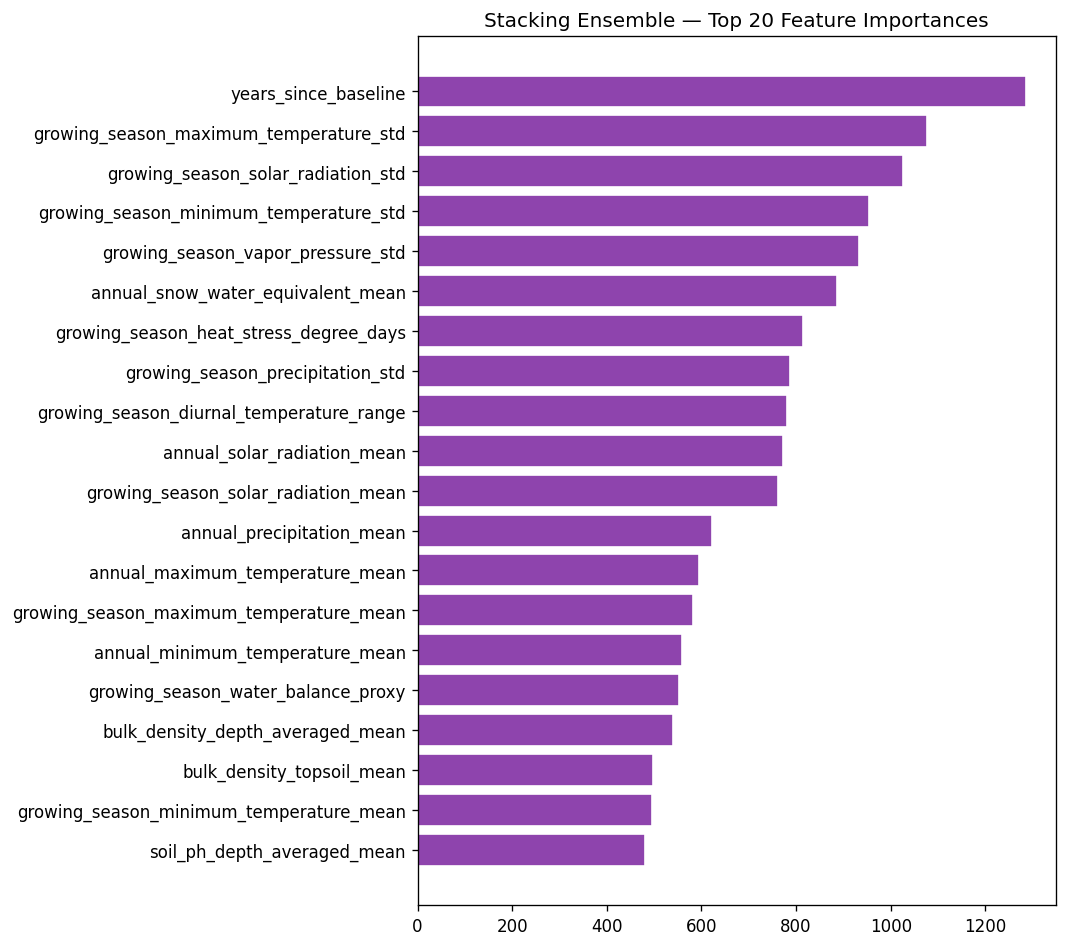


  Top-10 features:


,Importance
years_since_baseline,1285.089061
growing_season_maximum_temperature_std,1076.507211
growing_season_solar_radiation_std,1025.502031
growing_season_minimum_temperature_std,953.503316
growing_season_vapor_pressure_std,934.002158
annual_snow_water_equivalent_mean,886.501857
growing_season_heat_stress_degree_days,815.554673
growing_season_precipitation_std,786.501753
growing_season_diurnal_temperature_range,781.003073
annual_solar_radiation_mean,773.005572


In [ ]:
best_fold = folds[-1]
train_b = feat[feat['obs_year'] <= best_fold['train_max_year']]
test_b  = feat[feat['obs_year'] == best_fold['test_year']]
scaler_b = StandardScaler()
X_train_bs = scaler_b.fit_transform(train_b[feature_cols].fillna(0).values)
X_test_bs  = scaler_b.transform(test_b[feature_cols].fillna(0).values)
y_train_b, y_test_b = train_b[TARGET].values, test_b[TARGET].values

plot_model = final_candidates[FINAL_MODEL_NAME]
plot_model.fit(X_train_bs, y_train_b)
final_model = plot_model  # ← add this line
y_pred_final = plot_model.predict(X_test_bs)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(y_test_b, y_pred_final, alpha=0.4, s=15, color='#8E44AD')
lo, hi = min(y_test_b.min(), y_pred_final.min()), max(y_test_b.max(), y_pred_final.max())
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
rmse, r2 = np.sqrt(mean_squared_error(y_test_b, y_pred_final)), r2_score(y_test_b, y_pred_final)
ax.set_title(f'{FINAL_MODEL_NAME} — Test Year {best_fold["test_year"]}\nRMSE={rmse:.1f} kg/ha, R²={r2:.4f}')
ax.set_xlabel('Actual Yield (kg/ha)'); ax.set_ylabel('Predicted Yield (kg/ha)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/predicted_vs_actual_final.png', bbox_inches='tight')
plt.show()

# ── Feature importance: averaged across tuned ET/RF/XGB if stacked, else native ──
TOP_N = 20
def get_importances(model):
    if hasattr(model, 'feature_importances_'):
        return model.feature_importances_
    if hasattr(model, 'estimators_'):  # StackingRegressor base learners
        imps = [e.feature_importances_ for e in model.estimators_ if hasattr(e, 'feature_importances_')]
        return np.mean(imps, axis=0) if imps else None
    return None

importances = get_importances(final_model)
if importances is not None:
    idx = np.argsort(importances)[-TOP_N:]
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.barh([feature_cols[i] for i in idx], importances[idx], color='#8E44AD', edgecolor='white')
    ax.set_title(f'{FINAL_MODEL_NAME} — Top {TOP_N} Feature Importances')
    plt.tight_layout()
    plt.savefig('/content/feature_importance_final.png', bbox_inches='tight')
    plt.show()

    top10 = pd.Series(importances, index=feature_cols).sort_values(ascending=False).head(10)
    print('\n  Top-10 features:')
    display(top10.to_frame('Importance'))

##  STEP 12 — Final Summary & Download Outputs

In [ ]:
print('='*65)
print('PIPELINE COMPLETE')
print('\nModel Comparison (XGBoost / LightGBM / CatBoost / Stacking):')
display(final_summary_df)
print('\nBest Hyperparameters:')
print(best_params)
print(f'\n Final deployed model: {FINAL_MODEL_NAME}')


PIPELINE COMPLETE

Model Comparison (XGBoost / LightGBM / CatBoost / Stacking):


,Model,Mean RMSE (kg/ha),Mean R²
2,Stacking Ensemble,320.627790,0.808483
1,LightGBM,323.846454,0.804735
0,XGBoost,328.357955,0.799486



Best Hyperparameters:
{'XGBoost': {'n_estimators': 809, 'max_depth': 7, 'learning_rate': 0.08132085392477892}, 'LightGBM': {'n_estimators': 909, 'num_leaves': 54, 'learning_rate': 0.054229279797255184}}

🏆 Final deployed model: Stacking Ensemble
